# Nested Sampling in the General Gaussian Case Using MCMC

This notebook explains how to move from the **special case**, where we could sample exactly from the constrained prior, to the **general case**, where we instead use an **MCMC kernel** to sample approximately from

$$
\pi(	\theta \mid L(	\theta) > \ell).
$$

The goal is to answer the following points clearly:

1. why an MCMC sampler can target the constrained prior,
2. how this MCMC step is inserted into nested sampling,
3. how to implement the resulting algorithm,
4. how to run a few small numerical checks.

We keep the presentation practical and implementation-oriented.

## 1. Imports

We use:

- `numpy` for linear algebra and simulation,
- `scipy.special.logsumexp` for stable log-sums,
- `matplotlib` for the figures,
- `tqdm` for progress bars during repeated Monte Carlo experiments.

The notebook works in the Gaussian Bayesian model

$$
y_i \mid \theta \sim \mathcal N_d(\theta,\Sigma), \qquad
\theta \sim \mathcal N_d(0,I_d),
$$

with known covariance matrix `Sigma`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.special import logsumexp
from tqdm.auto import tqdm

# ---------------------------------------------------------------------
# Plot style
# ---------------------------------------------------------------------
# The goal is to keep the notebook readable without depending on seaborn.
plt.rcParams.update({
    "figure.figsize": (8.5, 5.2),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.titlesize": 13,
    "legend.frameon": False,
    "lines.linewidth": 2,
    "lines.markersize": 5,
})

def finish_plot(title=None, xlabel=None, ylabel=None, legend=True):
    """Small helper to make all figures look consistent."""
    ax = plt.gca()
    if title is not None:
        ax.set_title(title, pad=12)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    if legend:
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend()
    plt.tight_layout()
    plt.show()


def summarize_errors(estimates, true_value):
    """Return standard Monte Carlo summary statistics for log-evidence estimates."""
    estimates = np.asarray(estimates, dtype=float)
    errors = estimates - true_value
    return {
        "mean": np.mean(estimates),
        "std": np.std(estimates, ddof=1) if len(estimates) > 1 else 0.0,
        "bias": np.mean(errors),
        "rmse": np.sqrt(np.mean(errors**2)),
        "q05": np.quantile(estimates, 0.05),
        "q50": np.quantile(estimates, 0.50),
        "q95": np.quantile(estimates, 0.95),
    }


## 1.1. MCMC diagnostic utilities

The following helper functions compute autocorrelations and effective sample size (ESS).  
They are used only as diagnostics for the constrained MCMC kernels.


In [2]:
def autocorrelation_1d(x, max_lag=None):
    """
    Empirical autocorrelation function for a one-dimensional chain.

    Parameters
    ----------
    x : array-like, shape (n_samples,)
        Values of the Markov chain.
    max_lag : int or None
        Maximum lag to compute. If None, uses min(n_samples // 2, 100).

    Returns
    -------
    acf : np.ndarray
        Autocorrelation values from lag 0 to max_lag.
    """
    x = np.asarray(x, dtype=float)
    n = len(x)

    if n < 2:
        return np.array([1.0])

    if max_lag is None:
        max_lag = min(n // 2, 100)
    max_lag = min(max_lag, n - 1)

    x_centered = x - np.mean(x)
    var = np.dot(x_centered, x_centered) / n

    if var == 0:
        return np.ones(max_lag + 1)

    acf = np.empty(max_lag + 1)
    acf[0] = 1.0

    for lag in range(1, max_lag + 1):
        acf[lag] = np.dot(x_centered[:-lag], x_centered[lag:]) / ((n - lag) * var)

    return acf


def effective_sample_size_1d(x, max_lag=None):
    """
    Estimate the effective sample size of a one-dimensional MCMC chain.

    The estimator uses the initial positive sequence rule:
    it sums autocorrelations until the first non-positive autocorrelation.
    """
    x = np.asarray(x, dtype=float)
    n = len(x)

    if n <= 1:
        return float(n)

    acf = autocorrelation_1d(x, max_lag=max_lag)

    positive_acf = []
    for rho in acf[1:]:
        if rho <= 0:
            break
        positive_acf.append(rho)

    tau = 1.0 + 2.0 * np.sum(positive_acf)
    return n / tau


def mcmc_diagnostic_table(trace, names=None, max_lag=None):
    """
    Return ESS diagnostics for each coordinate of a trace.

    Parameters
    ----------
    trace : array-like
        Shape (n_samples,) or (n_samples, d).
    names : list[str] or None
        Names of the monitored quantities.
    max_lag : int or None
        Maximum lag used in the autocorrelation computation.
    """
    trace = np.asarray(trace, dtype=float)

    if trace.ndim == 1:
        trace = trace[:, None]

    n_samples, d = trace.shape

    if names is None:
        names = [f"coord_{j}" for j in range(d)]

    rows = []
    for j, name in enumerate(names):
        ess = effective_sample_size_1d(trace[:, j], max_lag=max_lag)
        rows.append({
            "quantity": name,
            "n_samples": n_samples,
            "ESS": ess,
            "ESS_ratio": ess / n_samples
        })

    return pd.DataFrame(rows)


## 2. General Gaussian model: data generation and exact benchmark

We work in the general Gaussian model, not in the simplified radial case.

For the performance study, it is still useful to keep a benchmark.  
Since this model is conjugate, the marginal likelihood has a closed form, so we can compare the nested sampling estimate with the exact `log-evidence`.

In [3]:
def simulate_gaussian_data(n, d, Sigma, theta_true=None, seed=None):
    """
    Simulate y_1, ..., y_n in R^d from N_d(theta_true, Sigma).
    """
    rng = np.random.default_rng(seed)
    if theta_true is None:
        theta_true = np.zeros(d)
    Y = rng.multivariate_normal(mean=theta_true, cov=Sigma, size=n)
    return Y


def posterior_parameters(Y, Sigma):
    """
    Posterior parameters for:
        y_i | theta ~ N_d(theta, Sigma)
        theta ~ N_d(0, I_d)
    """
    n, d = Y.shape
    Sigma_inv = np.linalg.inv(Sigma)
    Vn = np.linalg.inv(np.eye(d) + n * Sigma_inv)
    mn = Vn @ Sigma_inv @ np.sum(Y, axis=0)
    return mn, Vn


def true_log_evidence_general(Y, Sigma):
    """
    Closed-form log marginal likelihood in the general Gaussian model.
    """
    n, d = Y.shape
    Sigma_inv = np.linalg.inv(Sigma)

    A = np.eye(d) + n * Sigma_inv
    b = Sigma_inv @ np.sum(Y, axis=0)

    sign_Sigma, logdet_Sigma = np.linalg.slogdet(Sigma)
    sign_A, logdet_A = np.linalg.slogdet(A)
    if sign_Sigma <= 0 or sign_A <= 0:
        raise ValueError("Sigma and A must be positive definite.")

    quad1 = sum(y @ Sigma_inv @ y for y in Y)
    quad2 = b @ np.linalg.solve(A, b)

    logZ = (
        -0.5 * n * d * np.log(2 * np.pi)
        -0.5 * n * logdet_Sigma
        -0.5 * logdet_A
        -0.5 * (quad1 - quad2)
    )
    return logZ

## 3. Prior density and likelihood

In the general case, the likelihood is no longer radial in $\theta$, so we cannot reduce the constraint to a simple ball.

But we can still evaluate:

- the log-prior,
- the log-likelihood.

These are the only ingredients needed for a Metropolis-Hastings kernel.

In [4]:
def log_prior(theta):
    """
    Log-density of N_d(0, I_d), up to the normalizing constant.
    For MH with a symmetric proposal, the additive constant cancels.
    """
    theta = np.asarray(theta)
    return -0.5 * np.dot(theta, theta)


def prepare_gaussian_likelihood(Y, Sigma):
    """
    Precompute quantities used repeatedly by the Gaussian log-likelihood.

    This avoids recomputing Sigma^{-1} and log det(Sigma) thousands of times
    inside nested sampling and MCMC.
    """
    Y = np.asarray(Y)
    Sigma = np.asarray(Sigma)
    n, d = Y.shape

    Sigma_inv = np.linalg.inv(Sigma)
    sign, logdet = np.linalg.slogdet(Sigma)
    if sign <= 0:
        raise ValueError("Sigma must be positive definite.")

    const = -0.5 * n * d * np.log(2 * np.pi) - 0.5 * n * logdet

    return {
        "Y": Y,
        "Sigma": Sigma,
        "Sigma_inv": Sigma_inv,
        "const": const,
        "n": n,
        "d": d,
    }


def loglik_general(theta, Y, Sigma, cache=None):
    """
    Log-likelihood of Y given theta in the Gaussian model:
        y_i | theta ~ N_d(theta, Sigma).

    The optional `cache` argument is useful when the likelihood is evaluated
    many times with the same dataset.
    """
    if cache is None:
        cache = prepare_gaussian_likelihood(Y, Sigma)

    theta = np.asarray(theta)
    centered = cache["Y"] - theta
    quad = np.einsum("ni,ij,nj->", centered, cache["Sigma_inv"], centered)

    return cache["const"] - 0.5 * quad


## 4. Why an MCMC kernel can target the constrained prior

The target distribution we need inside nested sampling is

$$
\pi_\ell(\theta) \propto \pi(\theta)\,\mathbf{1}\{L(\theta) > \ell\}.
$$

This is simply the prior restricted to the admissible region.

A convenient idea is to use a **random-walk Metropolis-Hastings** proposal:

$$
\theta' = \theta + \varepsilon,
\qquad
\varepsilon \sim \mathcal{N}_d(0,\sigma_{\mathrm{prop}}^2 I_d).
$$

Because the proposal is symmetric, the Metropolis-Hastings ratio only involves the prior, provided the proposal satisfies the likelihood constraint. So the move is:

- if $L(\theta') \le \ell$, reject immediately,
- otherwise accept with probability

$$
\alpha(\theta,\theta')
=
\min\left(1,\frac{\pi(\theta')}{\pi(\theta)}\right).
$$

This leaves the truncated prior invariant.

So even though we cannot sample exactly from the constrained prior, we can sample approximately from it by running this Markov chain long enough.

## 5. Constrained Metropolis-Hastings kernel

The next function performs several Metropolis-Hastings steps targeting

$$
\pi(	\theta \mid L(	\theta) > \ell).
$$

A good initial state is any point that already satisfies the constraint.  
Inside nested sampling, a surviving live point is perfect for that.

In [5]:
def constrained_mh_sampler(
    theta0,
    logL_min,
    Y,
    Sigma,
    n_steps=50,
    proposal_scale=0.5,
    seed=None,
    return_trace=False,
    cache=None,
    show_progress=False,
    progress_desc="Constrained MH"
):
    """
    Run a random-walk MH chain targeting the constrained prior:
        pi(theta | L(theta) > L_min).

    Proposal:
        theta' = theta + proposal_scale * z,  z ~ N(0, I)

    Acceptance rule:
    - reject automatically if loglik(theta') <= logL_min,
    - otherwise accept with MH ratio based on the prior only,
      because the proposal is symmetric and the indicator constraint
      is enforced by rejection.
    """
    rng = np.random.default_rng(seed)
    theta = np.array(theta0, dtype=float).copy()
    d = theta.shape[0]

    if cache is None:
        cache = prepare_gaussian_likelihood(Y, Sigma)

    current_logprior = log_prior(theta)
    current_loglik = loglik_general(theta, Y, Sigma, cache=cache)

    if current_loglik <= logL_min:
        raise ValueError("Initial state does not satisfy the likelihood constraint.")

    accepted = 0
    trace = [theta.copy()] if return_trace else None

    iterator = range(n_steps)
    if show_progress:
        iterator = tqdm(iterator, total=n_steps, desc=progress_desc, leave=False)

    for _ in iterator:
        proposal = theta + proposal_scale * rng.normal(size=d)
        proposal_loglik = loglik_general(proposal, Y, Sigma, cache=cache)

        # Constraint enforcement
        if proposal_loglik <= logL_min:
            if return_trace:
                trace.append(theta.copy())
            continue

        proposal_logprior = log_prior(proposal)
        log_alpha = proposal_logprior - current_logprior

        if np.log(rng.uniform()) < min(0.0, log_alpha):
            theta = proposal
            current_logprior = proposal_logprior
            current_loglik = proposal_loglik
            accepted += 1

        if return_trace:
            trace.append(theta.copy())

    out = {
        "theta": theta,
        "acceptance_rate": accepted / n_steps if n_steps > 0 else np.nan
    }

    if return_trace:
        out["trace"] = np.array(trace)

    return out


## 6. Small sanity check for the constrained MCMC sampler

Before inserting the chain into nested sampling, it is good practice to test it separately.

We will:

1. simulate a small dataset,
2. choose a likelihood threshold,
3. start from a point satisfying the constraint,
4. run the constrained MCMC chain,
5. check the acceptance rate and a trace plot.

This does not prove correctness mathematically, but it helps detect obvious implementation mistakes.

In [13]:
# Small test problem
d_test = 2
n_test = 2000
Sigma_test = np.array([[1.0, 0.4],
                       [0.4, 1.5]])

Y_test = simulate_gaussian_data(n_test, d_test, Sigma_test, seed=123)

# Start from a prior draw, then keep trying until it satisfies the constraint
rng = np.random.default_rng(2024)
theta_candidates = rng.normal(size=(1000, d_test))
logliks = np.array([loglik_general(t, Y_test, Sigma_test) for t in theta_candidates])

# Pick a threshold below a reasonably high likelihood level
logL_min_test = np.quantile(logliks, 0.60)

valid_idx = np.where(logliks > logL_min_test)[0][0]
theta0_test = theta_candidates[valid_idx]

mh_out = constrained_mh_sampler(
    theta0_test,
    logL_min_test,
    Y_test,
    Sigma_test,
    n_steps=200,
    proposal_scale=0.4,
    seed=1,
    return_trace=True
)

print("Acceptance rate:", mh_out["acceptance_rate"])
print("Final state satisfies constraint:",
      loglik_general(mh_out["theta"], Y_test, Sigma_test) > logL_min_test)

Acceptance rate: 0.705
Final state satisfies constraint: True


### Trace of the constrained MCMC chain in dimension 2

Because the test is two-dimensional, we can visualize the trace.

The goal is not to produce a very advanced MCMC diagnostic here, only to see that the chain moves inside the admissible region instead of getting stuck immediately.

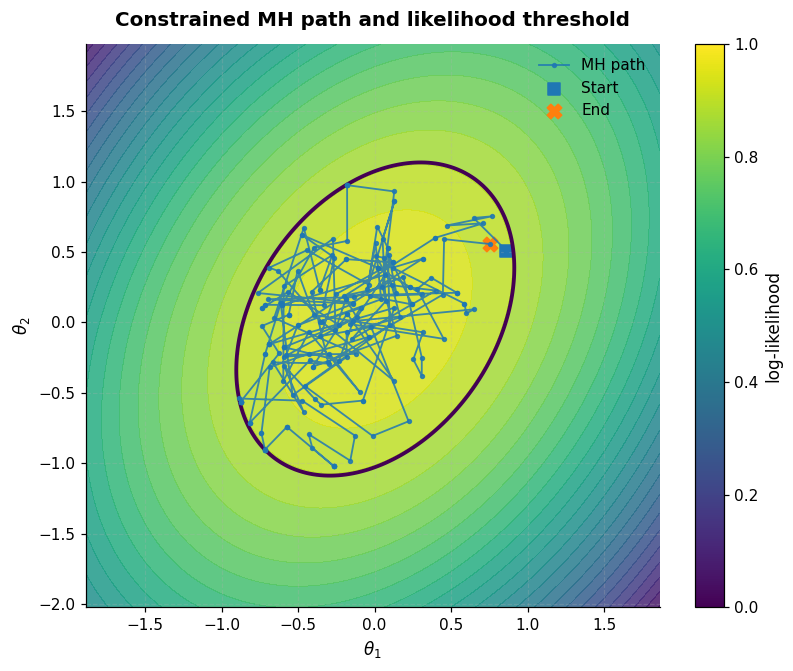

In [14]:
trace = mh_out["trace"]

# Evaluate the log-likelihood on a grid to show the constrained region.
x_min, x_max = trace[:, 0].min() - 1.0, trace[:, 0].max() + 1.0
y_min, y_max = trace[:, 1].min() - 1.0, trace[:, 1].max() + 1.0
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 160),
                     np.linspace(y_min, y_max, 160))

cache_test = prepare_gaussian_likelihood(Y_test, Sigma_test)
zz = np.empty_like(xx)
for i in range(xx.shape[0]):
    for j in range(xx.shape[1]):
        zz[i, j] = loglik_general(np.array([xx[i, j], yy[i, j]]), Y_test, Sigma_test, cache=cache_test)

plt.figure(figsize=(7.5, 6.2))
plt.contourf(xx, yy, zz, levels=25, alpha=0.85)
plt.contour(xx, yy, zz, levels=[logL_min_test], linewidths=2.5)
plt.plot(trace[:, 0], trace[:, 1], marker="o", markersize=2.5, linewidth=1.2, alpha=0.85, label="MH path")
plt.scatter(trace[0, 0], trace[0, 1], marker="s", s=70, label="Start")
plt.scatter(trace[-1, 0], trace[-1, 1], marker="X", s=90, label="End")
plt.colorbar(label="log-likelihood")
finish_plot(
    title="Constrained MH path and likelihood threshold",
    xlabel=r"$\theta_1$",
    ylabel=r"$\theta_2$",
)


### ESS and acceptance-rate diagnostics for the constrained chain

The next cell computes numerical diagnostics for the standalone constrained MCMC run.


Standalone constrained MH acceptance rate: 0.705


,quantity,n_samples,ESS,ESS_ratio
0,theta_1,201,28.1,0.140
1,theta_2,201,14.7,0.073
2,log_likelihood,201,25.2,0.125


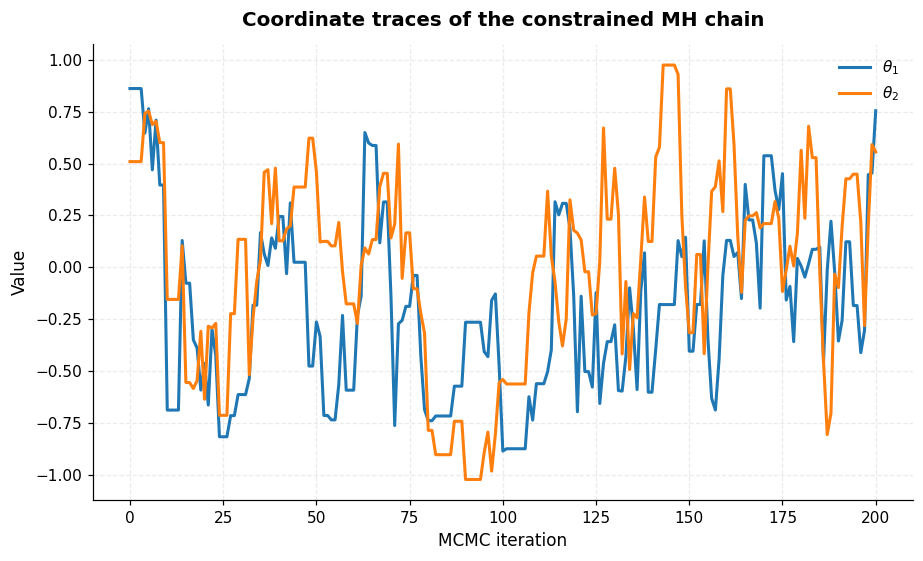

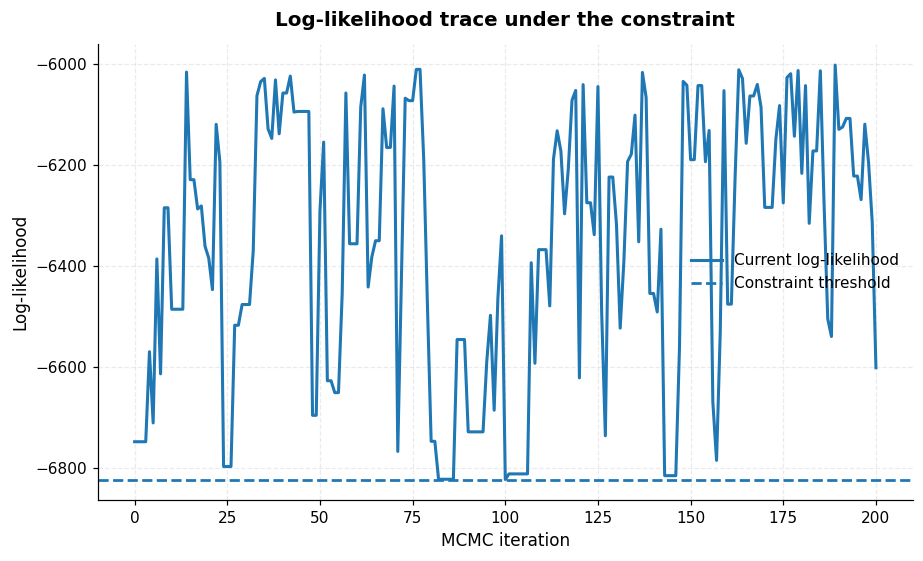

In [15]:
# Acceptance rate for the standalone constrained MCMC chain
standalone_acceptance_rate = mh_out["acceptance_rate"]

# ESS for each coordinate of theta along the chain
theta_names = [rf"theta_{j+1}" for j in range(trace.shape[1])]
ess_theta_table = mcmc_diagnostic_table(trace, names=theta_names)

# ESS for the log-likelihood along the chain
loglik_trace = np.array([
    loglik_general(theta, Y_test, Sigma_test, cache=cache_test)
    for theta in trace
])
ess_loglik_table = mcmc_diagnostic_table(loglik_trace, names=["log_likelihood"])

diagnostics_table = pd.concat([ess_theta_table, ess_loglik_table], ignore_index=True)

print(f"Standalone constrained MH acceptance rate: {standalone_acceptance_rate:.3f}")
display(diagnostics_table.style.format({"ESS": "{:.1f}", "ESS_ratio": "{:.3f}"}))

plt.figure()
for j in range(trace.shape[1]):
    plt.plot(trace[:, j], label=rf"$\theta_{j+1}$")
finish_plot(
    title="Coordinate traces of the constrained MH chain",
    xlabel="MCMC iteration",
    ylabel="Value",
)

plt.figure()
plt.plot(loglik_trace, label="Current log-likelihood")
plt.axhline(logL_min_test, linestyle="--", linewidth=1.8, label="Constraint threshold")
finish_plot(
    title="Log-likelihood trace under the constraint",
    xlabel="MCMC iteration",
    ylabel="Log-likelihood",
)


## 7. How to use this MCMC kernel inside nested sampling

The structure of nested sampling remains the same.

At each iteration:

1. keep a set of live points,
2. remove the one with smallest likelihood,
3. update the prior mass estimate,
4. add the dead-point contribution to the evidence,
5. replace the dead point with a new point drawn from the constrained prior.

The only difference from the special case is step 5.

Since we cannot sample exactly from

$$
\pi(	\theta \mid L(	\theta) > L_t),
$$

we do the following:

- choose one surviving live point as an initial state,
- run the constrained MCMC chain targeting that truncated prior,
- use the final state of the chain as the replacement live point.

This is the standard MCMC-within-NS idea.

## 8. Nested sampling with MCMC replacement

The function below implements nested sampling in the general case.

A few practical comments:

- the initial state of the MCMC chain is chosen among the surviving live points, because it automatically satisfies the constraint,
- the parameter `mcmc_steps` controls how long we run the chain before taking the new live point,
- the parameter `proposal_scale` controls the local size of MH moves,
- the final evidence estimate includes the remaining live-point contribution.

In [16]:
def nested_sampling_general_mcmc(
    Y,
    Sigma,
    N_live=100,
    max_iter=500,
    seed=None,
    use_random_shrinkage=True,
    mcmc_steps=50,
    proposal_scale=0.5,
    stop_tol=1e-10,
    return_path=False,
    show_progress=False,
    progress_desc="NS-MCMC"
):
    rng = np.random.default_rng(seed)
    n, d = Y.shape
    cache = prepare_gaussian_likelihood(Y, Sigma)

    # Initialize live points from the prior
    live_thetas = rng.normal(size=(N_live, d))
    live_logLs = np.array([
        loglik_general(theta, Y, Sigma, cache=cache)
        for theta in live_thetas
    ])

    X_prev = 1.0
    log_terms = []
    dead_logLs = []
    Xs = [X_prev]
    logZ_partial = []
    mh_acceptance_rates = []

    iterator = range(max_iter)
    if show_progress:
        iterator = tqdm(iterator, total=max_iter, desc=progress_desc, leave=True)

    for _ in iterator:
        # 1. Remove worst live point
        worst_idx = np.argmin(live_logLs)
        logL_t = live_logLs[worst_idx]
        dead_logLs.append(logL_t)

        # 2. Shrink prior mass
        if use_random_shrinkage:
            T_t = rng.beta(N_live, 1)
        else:
            T_t = np.exp(-1.0 / N_live)

        X_t = X_prev * T_t
        w_t = X_prev - X_t

        # 3. Add dead-point contribution
        log_terms.append(np.log(w_t) + logL_t)
        logZ_now = logsumexp(log_terms)
        logZ_partial.append(logZ_now)

        # 4. Stop if remaining possible evidence is negligible
        log_remaining_upper = np.log(X_t) + np.max(live_logLs)
        if log_remaining_upper - logZ_now < np.log(stop_tol):
            X_prev = X_t
            Xs.append(X_prev)
            break

        # 5. Choose a surviving live point to start the MCMC chain
        # We need a starting point satisfying the strict constraint L(theta) > L_t.
        # Usually every survivor is valid. The small filtering below protects us
        # against numerical ties in low-dimensional examples.
        survivor_indices = np.where(live_logLs > logL_t)[0]
        survivor_indices = survivor_indices[survivor_indices != worst_idx]

        if len(survivor_indices) == 0:
            # Extremely rare numerical-tie fallback: relax the threshold by one ulp.
            logL_for_mcmc = np.nextafter(logL_t, -np.inf)
            survivor_indices = np.delete(np.arange(N_live), worst_idx)
        else:
            logL_for_mcmc = logL_t

        start_idx = rng.choice(survivor_indices)
        theta_start = live_thetas[start_idx].copy()

        mh_seed = int(rng.integers(0, 10**9))
        mh_out = constrained_mh_sampler(
            theta0=theta_start,
            logL_min=logL_for_mcmc,
            Y=Y,
            Sigma=Sigma,
            n_steps=mcmc_steps,
            proposal_scale=proposal_scale,
            seed=mh_seed,
            return_trace=False,
            cache=cache,
            show_progress=False
        )

        theta_new = mh_out["theta"]
        logL_new = loglik_general(theta_new, Y, Sigma, cache=cache)
        mh_acceptance_rates.append(mh_out["acceptance_rate"])

        live_thetas[worst_idx] = theta_new
        live_logLs[worst_idx] = logL_new

        X_prev = X_t
        Xs.append(X_prev)

        if show_progress and hasattr(iterator, "set_postfix"):
            iterator.set_postfix({
                "logZ": f"{logZ_now:.2f}",
                "acc": f"{np.mean(mh_acceptance_rates):.2f}"
            })

    # Remaining live-point contribution
    log_live_meanL = logsumexp(live_logLs) - np.log(N_live)
    logZ_live = np.log(X_prev) + log_live_meanL

    logZ_hat_no_live = logsumexp(log_terms)
    logZ_hat = logsumexp([logZ_hat_no_live, logZ_live])

    out = {
        "logZ_hat": logZ_hat,
        "logZ_hat_no_live": logZ_hat_no_live,
        "dead_logLs": np.array(dead_logLs),
        "Xs": np.array(Xs),
        "live_logLs": live_logLs.copy(),
        "mean_mh_acceptance": np.mean(mh_acceptance_rates) if mh_acceptance_rates else np.nan,
        "mh_acceptance_rates": np.array(mh_acceptance_rates),
        "n_iter": len(dead_logLs),
    }

    if return_path:
        out["logZ_partial"] = np.array(logZ_partial)

    return out


## 9. One run of nested sampling with MCMC

We now run the full algorithm once on a moderate problem.

The first goal is interpretability:

- compare the final estimate to the exact log-evidence,
- look at the running estimate through time,
- inspect the average acceptance rate of the MCMC replacement step.

In [17]:
# Example problem
n = 25
d = 3
Sigma = np.array([[1.0, 0.2, 0.1],
                  [0.2, 1.5, 0.3],
                  [0.1, 0.3, 1.2]])

Y = simulate_gaussian_data(n, d, Sigma, seed=42)
logZ_true = true_log_evidence_general(Y, Sigma)

out_one = nested_sampling_general_mcmc(
    Y,
    Sigma,
    N_live=100,
    max_iter=600,
    seed=1,
    use_random_shrinkage=True,
    mcmc_steps=80,
    proposal_scale=0.45,
    stop_tol=1e-10,
    return_path=True,
    show_progress=True,
    progress_desc="One NS-MCMC run"
)

print(f"True log-evidence      : {logZ_true:.6f}")
print(f"NS-MCMC estimate       : {out_one['logZ_hat']:.6f}")
print(f"Error                  : {out_one['logZ_hat'] - logZ_true:.6f}")
print(f"Mean MH acceptance rate: {out_one['mean_mh_acceptance']:.3f}")

One NS-MCMC run:   0%|          | 0/600 [00:00<?, ?it/s]

True log-evidence      : -102.784743
NS-MCMC estimate       : -102.474230
Error                  : 0.310513
Mean MH acceptance rate: 0.272


### Acceptance rates inside NS-MCMC

The next cell records the acceptance rate of the constrained MCMC replacement step at each NS iteration.


,mean_acceptance,std_acceptance,min_acceptance,max_acceptance
0,0.272,0.223,0.000,0.812


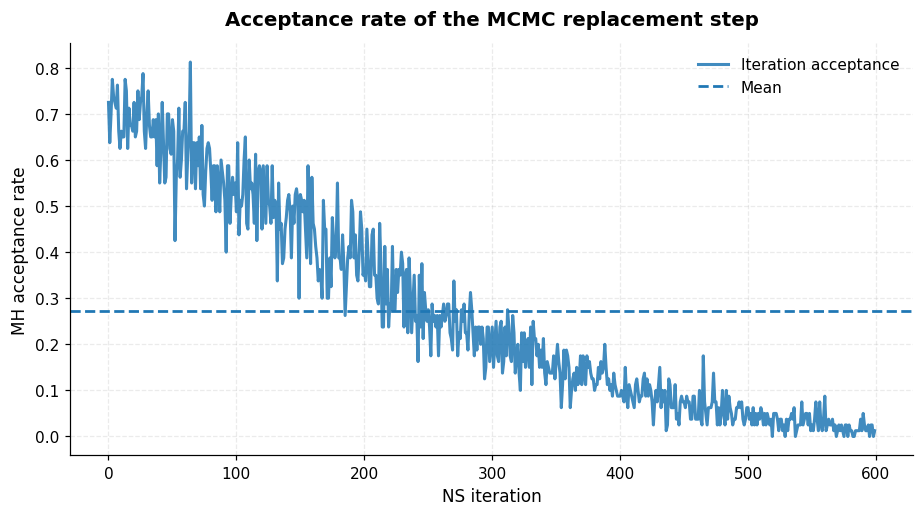

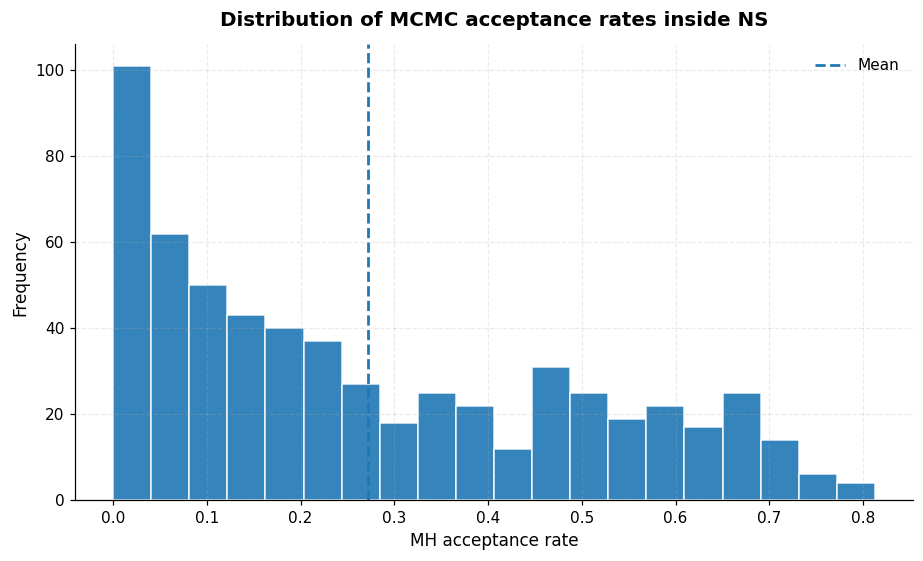

In [18]:
mh_acceptance_rates = out_one["mh_acceptance_rates"]

acceptance_summary = pd.DataFrame({
    "mean_acceptance": [np.mean(mh_acceptance_rates)],
    "std_acceptance": [np.std(mh_acceptance_rates, ddof=1)],
    "min_acceptance": [np.min(mh_acceptance_rates)],
    "max_acceptance": [np.max(mh_acceptance_rates)]
})

display(acceptance_summary.style.format("{:.3f}"))

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(mh_acceptance_rates, alpha=0.85, label="Iteration acceptance")
ax.axhline(np.mean(mh_acceptance_rates), linestyle="--", linewidth=1.8, label="Mean")
finish_plot(
    title="Acceptance rate of the MCMC replacement step",
    xlabel="NS iteration",
    ylabel="MH acceptance rate",
)

plt.figure()
plt.hist(mh_acceptance_rates, bins=20, edgecolor="white", alpha=0.9)
plt.axvline(np.mean(mh_acceptance_rates), linestyle="--", linewidth=1.8, label="Mean")
finish_plot(
    title="Distribution of MCMC acceptance rates inside NS",
    xlabel="MH acceptance rate",
    ylabel="Frequency",
)


### Convergence plot for one run

This plot shows how the nested sampling estimate is progressively built.

As before, the dashed line is the exact log-evidence.  
The purpose here is mostly pedagogical: we want to see whether the cumulative estimate stabilizes in a reasonable region.

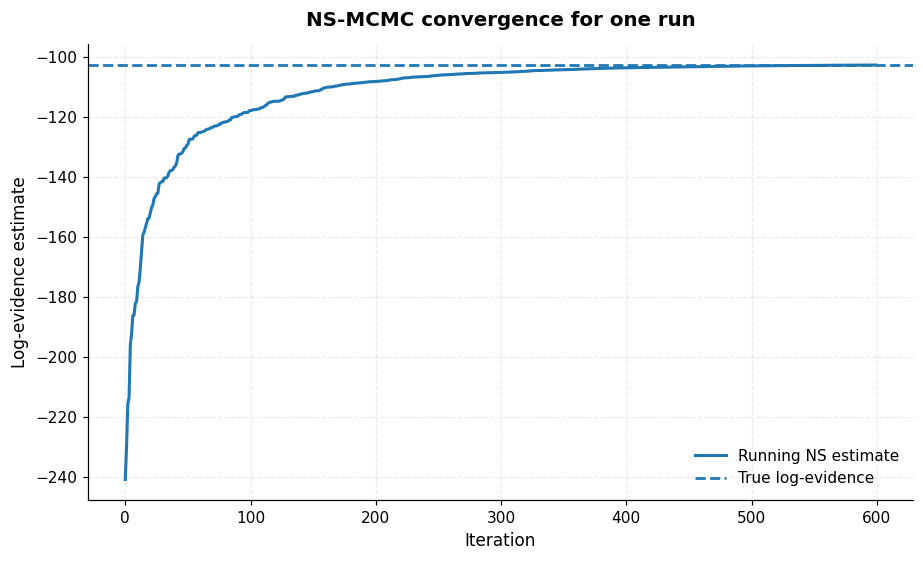

In [19]:
plt.figure()
plt.plot(out_one["logZ_partial"], label="Running NS estimate")
plt.axhline(logZ_true, linestyle="--", linewidth=1.8, label="True log-evidence")
finish_plot(
    title="NS-MCMC convergence for one run",
    xlabel="Iteration",
    ylabel="Log-evidence estimate",
)


### Prior-mass shrinkage

This plot is useful to keep the nested sampling mechanism visible even though the replacement step is now performed by MCMC.

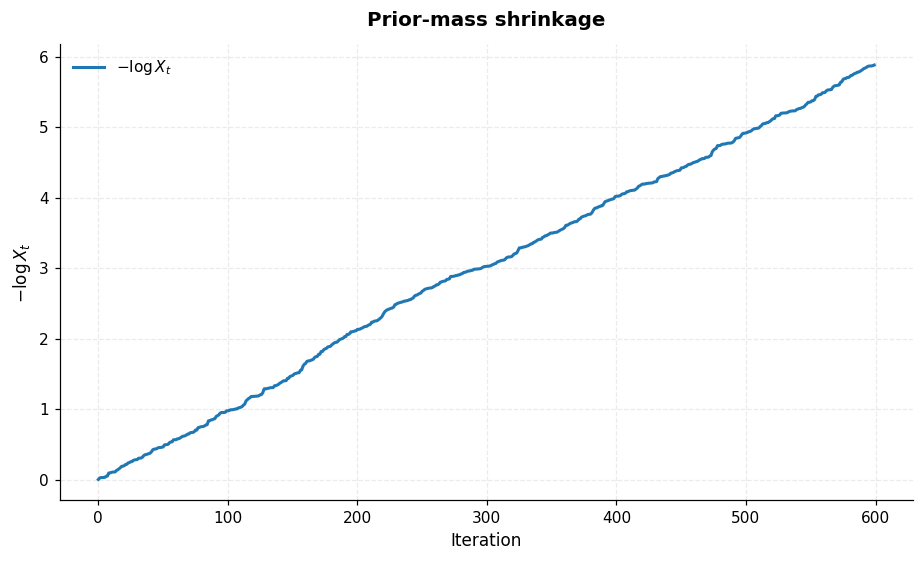

In [20]:
plt.figure()
plt.plot(-np.log(out_one["Xs"][1:]), label=r"$-\log X_t$")
finish_plot(
    title="Prior-mass shrinkage",
    xlabel="Iteration",
    ylabel=r"$-\log X_t$",
)


## 10. Repeated runs on one fixed dataset

We now repeat the full NS-MCMC algorithm several times on the same dataset.

The idea is simple: before discussing larger-scale behavior, we first want to know whether the algorithm gives reasonably stable estimates on one concrete problem.

In [21]:
def assess_ns_mcmc_single_dataset(
    Y,
    Sigma,
    N_live_list=(50, 100, 200),
    n_rep=40,
    max_iter=500,
    mcmc_steps=50,
    proposal_scale=0.5,
    seed=12345,
    show_progress=True
):
    true_logZ = true_log_evidence_general(Y, Sigma)
    rng = np.random.default_rng(seed)
    results = {}

    outer = N_live_list
    if show_progress:
        outer = tqdm(N_live_list, desc="Live-point settings")

    for N_live in outer:
        estimates = []
        acceptances = []

        inner = range(n_rep)
        if show_progress:
            inner = tqdm(inner, total=n_rep, desc=f"N_live={N_live}", leave=False)

        for _ in inner:
            run_seed = int(rng.integers(0, 10**9))
            out = nested_sampling_general_mcmc(
                Y,
                Sigma,
                N_live=N_live,
                max_iter=max_iter,
                seed=run_seed,
                use_random_shrinkage=True,
                mcmc_steps=mcmc_steps,
                proposal_scale=proposal_scale,
                stop_tol=1e-10,
                return_path=False,
                show_progress=False
            )
            estimates.append(out["logZ_hat"])
            acceptances.append(out["mean_mh_acceptance"])

        estimates = np.array(estimates)
        stats = summarize_errors(estimates, true_logZ)

        results[N_live] = {
            "true_logZ": true_logZ,
            "mean_logZ_hat": stats["mean"],
            "std_logZ_hat": stats["std"],
            "bias_logZ": stats["bias"],
            "rmse_logZ": stats["rmse"],
            "q05": stats["q05"],
            "q50": stats["q50"],
            "q95": stats["q95"],
            "mean_acceptance": np.mean(acceptances),
            "estimates": estimates,
            "errors": estimates - true_logZ
        }

    return results


In [22]:
results_one_dataset = assess_ns_mcmc_single_dataset(
    Y,
    Sigma,
    N_live_list=(50, 100, 200),
    n_rep=40,
    max_iter=500,
    mcmc_steps=80,
    proposal_scale=0.45,
    seed=2024
)

for N_live, res in results_one_dataset.items():
    print(
        f"N_live={N_live:3d} | "
        f"mean={res['mean_logZ_hat']:.6f} | "
        f"std={res['std_logZ_hat']:.6f} | "
        f"bias={res['bias_logZ']:.6f} | "
        f"rmse={res['rmse_logZ']:.6f} | "
        f"mean_acceptance={res['mean_acceptance']:.3f}"
    )

Live-point settings:   0%|          | 0/3 [00:00<?, ?it/s]

N_live=50:   0%|          | 0/40 [00:00<?, ?it/s]

N_live=100:   0%|          | 0/40 [00:00<?, ?it/s]

N_live=200:   0%|          | 0/40 [00:00<?, ?it/s]

N_live= 50 | mean=-102.791027 | std=0.477919 | bias=-0.006284 | rmse=0.471949 | mean_acceptance=0.181
N_live=100 | mean=-102.770947 | std=0.313916 | bias=0.013797 | rmse=0.310274 | mean_acceptance=0.350
N_live=200 | mean=-102.759963 | std=0.203814 | bias=0.024781 | rmse=0.202771 | mean_acceptance=0.529


### Summary table for repeated NS-MCMC runs

In [23]:
summary_one_dataset = pd.DataFrame([
    {
        "N_live": N_live,
        "mean_logZ_hat": res["mean_logZ_hat"],
        "std_logZ_hat": res["std_logZ_hat"],
        "bias_logZ": res["bias_logZ"],
        "rmse_logZ": res["rmse_logZ"],
        "q05": res["q05"],
        "q50": res["q50"],
        "q95": res["q95"],
        "mean_acceptance": res["mean_acceptance"],
    }
    for N_live, res in results_one_dataset.items()
]).sort_values("N_live")

display(summary_one_dataset.style.format({
    "mean_logZ_hat": "{:.4f}",
    "std_logZ_hat": "{:.4f}",
    "bias_logZ": "{:.4f}",
    "rmse_logZ": "{:.4f}",
    "q05": "{:.4f}",
    "q50": "{:.4f}",
    "q95": "{:.4f}",
    "mean_acceptance": "{:.3f}",
}))


,N_live,mean_logZ_hat,std_logZ_hat,bias_logZ,rmse_logZ,q05,q50,q95,mean_acceptance
0,50,-102.7910,0.4779,-0.0063,0.4719,-103.4824,-102.8156,-101.9399,0.181
1,100,-102.7709,0.3139,0.0138,0.3103,-103.3523,-102.7677,-102.3374,0.350
2,200,-102.7600,0.2038,0.0248,0.2028,-103.0466,-102.7207,-102.4940,0.529


### Boxplots of the repeated estimates

This figure gives a quick visual summary of the repeated-run variability.  
We keep this part short on purpose: the point here is mainly to confirm that the NS-MCMC procedure behaves sensibly.

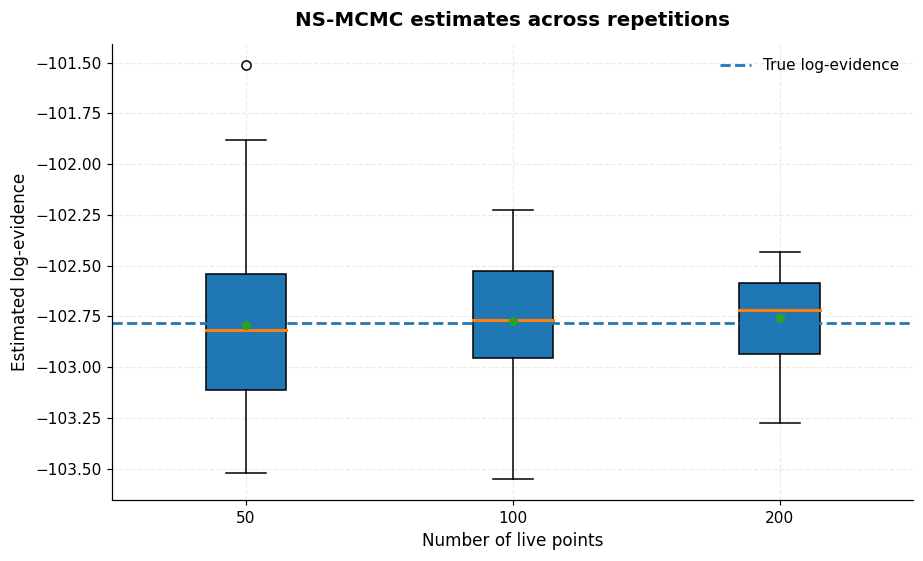

In [24]:
N_vals = sorted(results_one_dataset.keys())
data = [results_one_dataset[N]["estimates"] for N in N_vals]
true_val = results_one_dataset[N_vals[0]]["true_logZ"]

plt.figure(figsize=(8.5, 5.2))
plt.boxplot(
    data,
    labels=[str(N) for N in N_vals],
    showmeans=True,
    patch_artist=True,
    medianprops={"linewidth": 2},
    meanprops={"marker": "o", "markersize": 5},
)
plt.axhline(true_val, linestyle="--", linewidth=1.8, label="True log-evidence")
finish_plot(
    title="NS-MCMC estimates across repetitions",
    xlabel="Number of live points",
    ylabel="Estimated log-evidence",
)


## 11. Small test on the MCMC budget

In the general case, a key practical question is how many MCMC steps should be used when generating the replacement live point.

We do a small comparison across a few values of `mcmc_steps`, keeping everything else fixed.

This is not meant to be an exhaustive study, only a practical diagnostic.

In [25]:
def assess_mcmc_budget(
    Y,
    Sigma,
    mcmc_steps_list=(10, 30, 80, 150),
    n_rep=30,
    N_live=100,
    max_iter=500,
    proposal_scale=0.45,
    seed=321,
    show_progress=True
):
    true_logZ = true_log_evidence_general(Y, Sigma)
    rng = np.random.default_rng(seed)
    results = {}

    outer = mcmc_steps_list
    if show_progress:
        outer = tqdm(mcmc_steps_list, desc="MCMC budgets")

    for mcmc_steps in outer:
        estimates = []
        acceptances = []

        inner = range(n_rep)
        if show_progress:
            inner = tqdm(inner, total=n_rep, desc=f"K={mcmc_steps}", leave=False)

        for _ in inner:
            run_seed = int(rng.integers(0, 10**9))
            out = nested_sampling_general_mcmc(
                Y,
                Sigma,
                N_live=N_live,
                max_iter=max_iter,
                seed=run_seed,
                mcmc_steps=mcmc_steps,
                proposal_scale=proposal_scale,
                return_path=False,
                show_progress=False
            )
            estimates.append(out["logZ_hat"])
            acceptances.append(out["mean_mh_acceptance"])

        estimates = np.array(estimates)
        stats = summarize_errors(estimates, true_logZ)

        results[mcmc_steps] = {
            **stats,
            "mean_acceptance": np.mean(acceptances),
            "estimates": estimates,
        }

    return results


In [26]:
budget_results = assess_mcmc_budget(
    Y,
    Sigma,
    mcmc_steps_list=(10, 30, 80, 150),
    n_rep=30,
    N_live=100,
    max_iter=500,
    proposal_scale=0.45,
    seed=321
)

for msteps, res in budget_results.items():
    print(
        f"mcmc_steps={msteps:3d} | "
        f"mean={res['mean']:.6f} | "
        f"std={res['std']:.6f} | "
        f"bias={res['bias']:.6f} | "
        f"rmse={res['rmse']:.6f} | "
        f"mean_acceptance={res['mean_acceptance']:.3f}"
    )

MCMC budgets:   0%|          | 0/4 [00:00<?, ?it/s]

K=10:   0%|          | 0/30 [00:00<?, ?it/s]

K=30:   0%|          | 0/30 [00:00<?, ?it/s]

K=80:   0%|          | 0/30 [00:00<?, ?it/s]

K=150:   0%|          | 0/30 [00:00<?, ?it/s]

mcmc_steps= 10 | mean=-102.828218 | std=0.282134 | bias=-0.043475 | rmse=0.280778 | mean_acceptance=0.349
mcmc_steps= 30 | mean=-102.837633 | std=0.259781 | bias=-0.052889 | rmse=0.260833 | mean_acceptance=0.350
mcmc_steps= 80 | mean=-102.798502 | std=0.206520 | bias=-0.013759 | rmse=0.203515 | mean_acceptance=0.350
mcmc_steps=150 | mean=-102.779197 | std=0.305447 | bias=0.005546 | rmse=0.300365 | mean_acceptance=0.351


### RMSE as a function of the MCMC budget

If increasing the MCMC budget improves the estimate, we should see the RMSE decrease or at least stabilize.  
In practice, the behavior may not be perfectly monotone because the experiment is still Monte Carlo and kept deliberately small.

,mcmc_steps,bias,rmse,mean_acceptance
0,10,-0.0435,0.2808,0.349
1,30,-0.0529,0.2608,0.350
2,80,-0.0138,0.2035,0.350
3,150,0.0055,0.3004,0.351


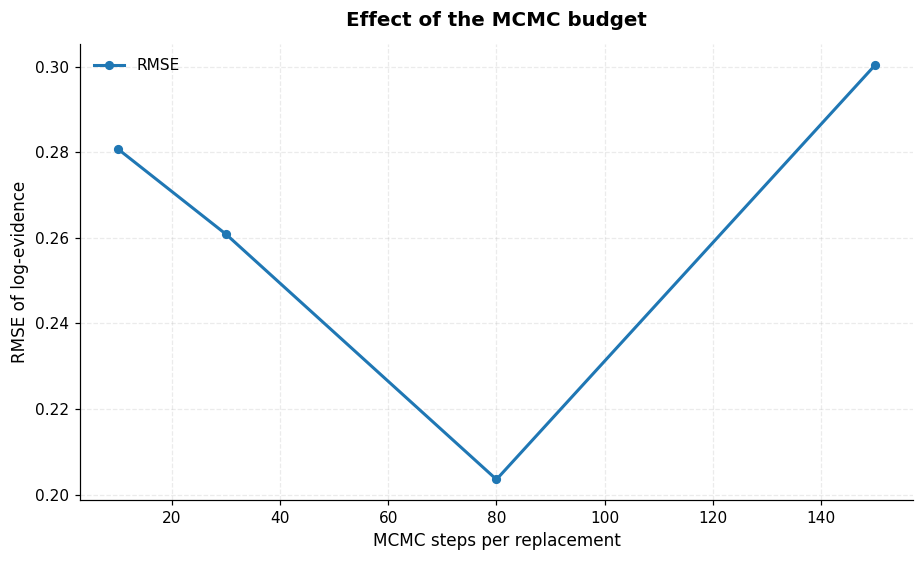

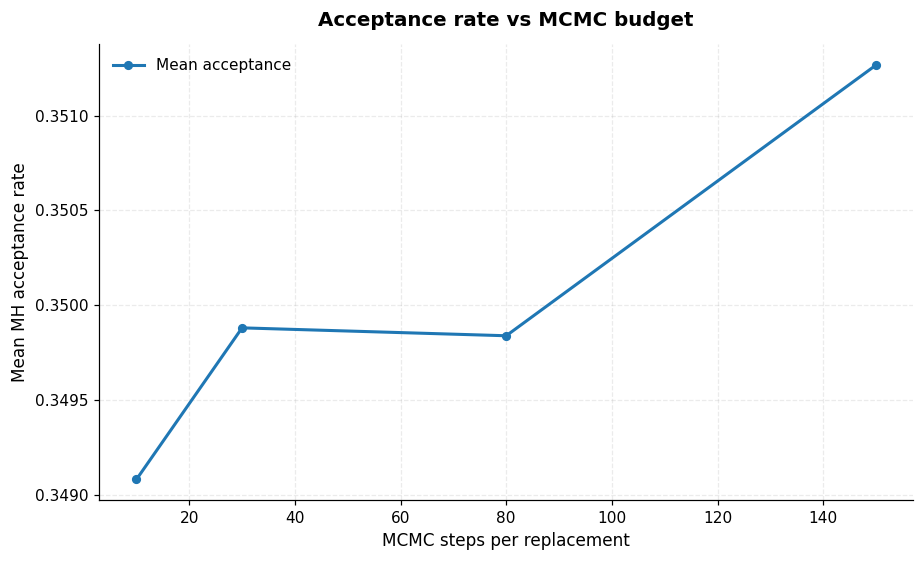

In [27]:
m_vals = sorted(budget_results.keys())
rmse_vals = [budget_results[m]["rmse"] for m in m_vals]
bias_vals = [budget_results[m]["bias"] for m in m_vals]
acc_vals = [budget_results[m]["mean_acceptance"] for m in m_vals]

budget_table = pd.DataFrame({
    "mcmc_steps": m_vals,
    "bias": bias_vals,
    "rmse": rmse_vals,
    "mean_acceptance": acc_vals,
})
display(budget_table.style.format({
    "bias": "{:.4f}",
    "rmse": "{:.4f}",
    "mean_acceptance": "{:.3f}",
}))

plt.figure()
plt.plot(m_vals, rmse_vals, marker="o", label="RMSE")
finish_plot(
    title="Effect of the MCMC budget",
    xlabel="MCMC steps per replacement",
    ylabel="RMSE of log-evidence",
)

plt.figure()
plt.plot(m_vals, acc_vals, marker="o", label="Mean acceptance")
finish_plot(
    title="Acceptance rate vs MCMC budget",
    xlabel="MCMC steps per replacement",
    ylabel="Mean MH acceptance rate",
)


## 12. Optional small sensitivity test for the proposal scale

Another practical tuning parameter is the proposal scale of the random-walk Metropolis kernel.

If the proposal scale is too small, the chain moves slowly.  
If it is too large, most proposals violate the likelihood constraint or get rejected by the prior ratio.

So it is useful to do a small sensitivity check.

In [28]:
def assess_proposal_scale(
    Y,
    Sigma,
    proposal_scales=(0.15, 0.3, 0.45, 0.8),
    n_rep=25,
    N_live=100,
    max_iter=500,
    mcmc_steps=80,
    seed=999,
    show_progress=True
):
    true_logZ = true_log_evidence_general(Y, Sigma)
    rng = np.random.default_rng(seed)
    results = {}

    outer = proposal_scales
    if show_progress:
        outer = tqdm(proposal_scales, desc="Proposal scales")

    for scale in outer:
        estimates = []
        acceptances = []

        inner = range(n_rep)
        if show_progress:
            inner = tqdm(inner, total=n_rep, desc=f"scale={scale:.2f}", leave=False)

        for _ in inner:
            run_seed = int(rng.integers(0, 10**9))
            out = nested_sampling_general_mcmc(
                Y,
                Sigma,
                N_live=N_live,
                max_iter=max_iter,
                seed=run_seed,
                mcmc_steps=mcmc_steps,
                proposal_scale=scale,
                return_path=False,
                show_progress=False
            )
            estimates.append(out["logZ_hat"])
            acceptances.append(out["mean_mh_acceptance"])

        estimates = np.array(estimates)
        stats = summarize_errors(estimates, true_logZ)

        results[scale] = {
            **stats,
            "mean_acceptance": np.mean(acceptances),
            "estimates": estimates,
        }

    return results


In [29]:
scale_results = assess_proposal_scale(
    Y,
    Sigma,
    proposal_scales=(0.15, 0.3, 0.45, 0.8),
    n_rep=25,
    N_live=100,
    max_iter=500,
    mcmc_steps=80,
    seed=999
)

for scale, res in scale_results.items():
    print(
        f"proposal_scale={scale:.2f} | "
        f"rmse={res['rmse']:.6f} | "
        f"mean_acceptance={res['mean_acceptance']:.3f}"
    )

Proposal scales:   0%|          | 0/4 [00:00<?, ?it/s]

scale=0.15:   0%|          | 0/25 [00:00<?, ?it/s]

scale=0.30:   0%|          | 0/25 [00:00<?, ?it/s]

scale=0.45:   0%|          | 0/25 [00:00<?, ?it/s]

scale=0.80:   0%|          | 0/25 [00:00<?, ?it/s]

proposal_scale=0.15 | rmse=0.332023 | mean_acceptance=0.719
proposal_scale=0.30 | rmse=0.162565 | mean_acceptance=0.502
proposal_scale=0.45 | rmse=0.280545 | mean_acceptance=0.349
proposal_scale=0.80 | rmse=0.243112 | mean_acceptance=0.174


,proposal_scale,bias,rmse,mean_acceptance
0,0.15,0.0032,0.3320,0.719
1,0.30,-0.0410,0.1626,0.502
2,0.45,0.0149,0.2805,0.349
3,0.80,0.0479,0.2431,0.174


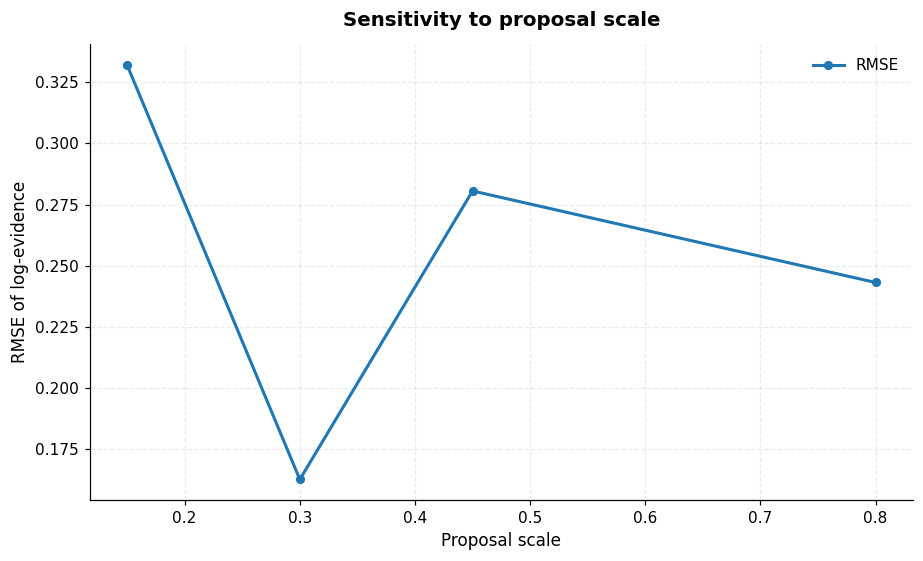

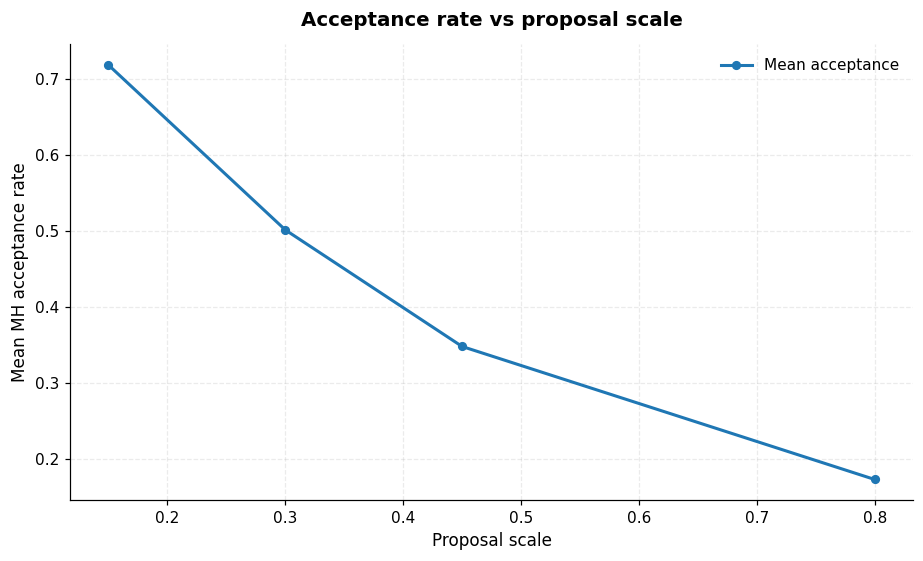

In [30]:
scales = sorted(scale_results.keys())
rmse_vals = [scale_results[s]["rmse"] for s in scales]
bias_vals = [scale_results[s]["bias"] for s in scales]
acc_vals = [scale_results[s]["mean_acceptance"] for s in scales]

scale_table = pd.DataFrame({
    "proposal_scale": scales,
    "bias": bias_vals,
    "rmse": rmse_vals,
    "mean_acceptance": acc_vals,
})
display(scale_table.style.format({
    "proposal_scale": "{:.2f}",
    "bias": "{:.4f}",
    "rmse": "{:.4f}",
    "mean_acceptance": "{:.3f}",
}))

plt.figure()
plt.plot(scales, rmse_vals, marker="o", label="RMSE")
finish_plot(
    title="Sensitivity to proposal scale",
    xlabel="Proposal scale",
    ylabel="RMSE of log-evidence",
)

plt.figure()
plt.plot(scales, acc_vals, marker="o", label="Mean acceptance")
finish_plot(
    title="Acceptance rate vs proposal scale",
    xlabel="Proposal scale",
    ylabel="Mean MH acceptance rate",
)


## 13. Conclusion

The main message of this notebook is the following.

In the general case, we can no longer sample exactly from the constrained prior, but we can still implement nested sampling by replacing the exact draw with an MCMC draw targeting

$$
\pi(	\theta \mid L(	\theta) > \ell).
$$

The procedure is:

1. remove the worst live point,
2. define the likelihood threshold from that point,
3. start an MCMC chain from a surviving live point,
4. run a constrained Metropolis-Hastings kernel,
5. use the final state as the new live point.

This produces a practical **NS-MCMC algorithm**.

Compared with the special case, the main new difficulty is no longer the nested sampling formula itself, but rather the quality of the constrained MCMC exploration.  
That is why the two most important practical tuning parameters are:

- the number of MCMC steps per replacement,
- the proposal scale.